<a href="https://colab.research.google.com/github/ashishsingh752/SolarEnergyPredictionUsingML/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing all the Necessary Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib.dates as mdates  # Import for date formatting in plots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

Define the constant for the solar power calculation

In [8]:
# Constants for the formula
PV_rating = 1  # PV rating in kW
P_STC = 1  # Nominal PV power under standard conditions (kW)
F_PV = 0.8  # PV derating factor
G_STC = 1  # Solar radiation under STC (kW/m²)
T_STC = 25  # Temperature under STC (°C)
C_T = 0.0011  # Temperature coefficient of power (for a-Si, °C)
NOCT = 45  # Normal Operating Cell Temperature (°C)

Importing the Dataset

In [9]:
# Step 1: Load the CSV data
data = pd.read_csv('/content/weatherData.csv')

# Combine 'Date' and 'Time' columns into a single 'DATE_TIME' column
data['DATE_TIME'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d-%m-%Y %H:%M')

In [11]:
# Step 2: Data Preprocessing
# Select relevant features
features = ['Temperature', 'SolarRadiation','WindSpeed', 'PowerConsumption_Zone1']
target = ['Solar Energy']

X = data[features]
y = data[target]

# Convert features to numeric, coercing errors to NaN
X[features] = X[features].apply(pd.to_numeric, errors='coerce')
y[target] = y[target].apply(pd.to_numeric, errors='coerce')

# Handle missing values
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)


<ipython-input-11-7450bc555a69>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[features] = X[features].apply(pd.to_numeric, errors='coerce')
<ipython-input-11-7450bc555a69>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[target] = y[target].apply(pd.to_numeric, errors='coerce')
<ipython-input-11-7450bc555a69>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

In [12]:
# Step 3: Add PV power generation formula
# Calculate cell temperature (T_C)
data['T_C'] = data['Temperature'] + (NOCT - 20) * (data['SolarRadiation'] / G_STC)

# Calculate PV power using the formula
data['P_PV'] =(PV_rating * P_STC * F_PV * (data['SolarRadiation'] / G_STC) *
               (1 + (data['T_C'] - T_STC) * C_T)) / 1000


In [13]:
# Use the calculated PV power as the target variable
y = data[['P_PV']]


In [14]:
# Step 4: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
# Step 5: Normalize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

Forecasting the Weather Parameter

In [16]:
# Step 6: Build individual models for each weather parameter
# Model for Temperature ('Temperature')
model_temp = Sequential()
model_temp.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_temp.add(Dropout(0.2))
model_temp.add(Dense(64, activation='relu'))
model_temp.add(Dropout(0.2))
model_temp.add(Dense(32, activation='relu'))
model_temp.add(Dense(1, activation='linear'))
model_temp.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_temp.fit(X_train_scaled, X_train['Temperature'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['Temperature']))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 219.3182 - mse: 219.3182 - val_loss: 1.2665 - val_mse: 1.2665
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.8974 - mse: 7.8974 - val_loss: 0.1698 - val_mse: 0.1698
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9931 - mse: 5.9931 - val_loss: 0.2417 - val_mse: 0.2417
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5.0254 - mse: 5.0254 - val_loss: 0.1640 - val_mse: 0.1640
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.4204 - mse: 4.4204 - val_loss: 0.0344 - val_mse: 0.0344
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.5473 - mse: 3.5473 - val_loss: 0.3186 - val_mse: 0.3186
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.9099 - mse: 2.9099 - val_loss: 0.0996 - val_mse: 0.0996
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3352 - mse: 2.3352 - val_loss: 0.0735 - val_mse: 0.0735
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 

In [17]:
# Model for Solar Radiation ('SolarRadiation')
model_rad = Sequential()
model_rad.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_rad.add(Dropout(0.2))
model_rad.add(Dense(64, activation='relu'))
model_rad.add(Dropout(0.2))
model_rad.add(Dense(32, activation='relu'))
model_rad.add(Dropout(0.2))
model_rad.add(Dense(16, activation='relu'))
model_rad.add(Dense(1, activation='relu'))
model_rad.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_rad.fit(X_train_scaled, X_train['SolarRadiation'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['SolarRadiation']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 66619.0234 - mse: 66619.0234 - val_loss: 105.7018 - val_mse: 105.7018
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3049.6199 - mse: 3049.6199 - val_loss: 642.6953 - val_mse: 642.6953
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2993.5942 - mse: 2993.5942 - val_loss: 130.2642 - val_mse: 130.2642
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2813.5940 - mse: 2813.5940 - val_loss: 21.9002 - val_mse: 21.9002
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2828.7280 - mse: 2828.7280 - val_loss: 160.5906 - val_mse: 160.5906
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2671.0303 - mse: 2671.0303 - val_loss: 114.0640 - val_mse: 114.0640
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2591.4688 - mse: 2591.4688 - val_loss: 89.9786 - val_mse: 89.9786
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2565.0613 - mse: 2565.0613 - val_loss: 128.2649 - val_mse

In [18]:
# Model for Wind Speed ('Wind Speed')
model_wind = Sequential()
model_wind.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_wind.add(Dropout(0.2))
model_wind.add(Dense(64, activation='relu'))
model_wind.add(Dropout(0.2))
model_wind.add(Dense(32, activation='relu'))
model_wind.add(Dense(1, activation='linear'))
model_wind.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_wind.fit(X_train_scaled, X_train['WindSpeed'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['WindSpeed']))



Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 13.0409 - mse: 13.0409 - val_loss: 0.0867 - val_mse: 0.0867
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6720 - mse: 0.6720 - val_loss: 0.0985 - val_mse: 0.0985
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5390 - mse: 0.5390 - val_loss: 0.0115 - val_mse: 0.0115
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4405 - mse: 0.4405 - val_loss: 0.0256 - val_mse: 0.0256
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3666 - mse: 0.3666 - val_loss: 0.0148 - val_mse: 0.0148
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3273 - mse: 0.3273 - val_loss: 0.0170 - val_mse: 0.0170
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2757 - mse: 0.2757 - val_loss: 0.0405 - val_mse: 0.0405
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2356 - mse: 0.2356 - val_loss: 0.1052 - val_mse: 0.1052
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.226

In [19]:
# Model for PowerConsumption_Zone1 ('PowerConsumption_Zone1')
model_PowerConsumption = Sequential()
model_PowerConsumption.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PowerConsumption.add(Dropout(0.2))
model_PowerConsumption.add(Dense(64, activation='relu'))
model_PowerConsumption.add(Dropout(0.2))
model_PowerConsumption.add(Dense(32, activation='relu'))
model_PowerConsumption.add(Dense(1, activation='relu'))
model_PowerConsumption.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PowerConsumption.fit(X_train_scaled, X_train['PowerConsumption_Zone1'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PowerConsumption_Zone1']))



Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 356.4955 - mse: 356.4955 - val_loss: 2.5486 - val_mse: 2.5486
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.7019 - mse: 9.7019 - val_loss: 0.5258 - val_mse: 0.5258
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.7527 - mse: 7.7527 - val_loss: 0.2931 - val_mse: 0.2931
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.1071 - mse: 7.1071 - val_loss: 0.1442 - val_mse: 0.1442
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.3890 - mse: 6.3890 - val_loss: 1.4935 - val_mse: 1.4935
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.7661 - mse: 5.7661 - val_loss: 0.2632 - val_mse: 0.2632
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.5384 - mse: 5.5384 - val_loss: 0.0621 - val_mse: 0.0621
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.9327 - mse: 4.9327 - val_loss: 0.2833 - val_mse: 0.2833
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.3

Choose Date to  predict the Solar and Wind Power for each Person

In [26]:
start_time = pd.to_datetime('21-06-2024 00:00', format='%d-%m-%Y %H:%M')
end_time = start_time + pd.Timedelta(days=1)
day_data = data[(data['DATE_TIME'] >= start_time) & (data['DATE_TIME'] < end_time)]
# Ensure that 'day_X' contains the same columns in the same order as the scaler was fitted
day_X = day_data[features]  # Use 'features' variable for consistent columns
day_X_scaled = scaler_X.transform(day_X)  # Normalize features

# Step 8: Forecast weather parameters for the day
day_temp_pred_scaled = model_temp.predict(day_X_scaled)
day_rad_pred_scaled = model_rad.predict(day_X_scaled)
day_wind_pred_scaled = model_wind.predict(day_X_scaled)
day_PowerConsumption_Zone1_scaled = model_PowerConsumption.predict(day_X_scaled)

# Inverse transform the predictions to get actual forecasted values
day_temp_pred = scaler_y.inverse_transform(day_temp_pred_scaled)
day_rad_pred = scaler_y.inverse_transform(day_rad_pred_scaled)
day_wind_pred = scaler_y.inverse_transform(day_wind_pred_scaled)
day_PowerConsumption_Zone1_pred = scaler_y.inverse_transform(day_PowerConsumption_Zone1_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Plot Solar Power for Five Persons with different PV Rating

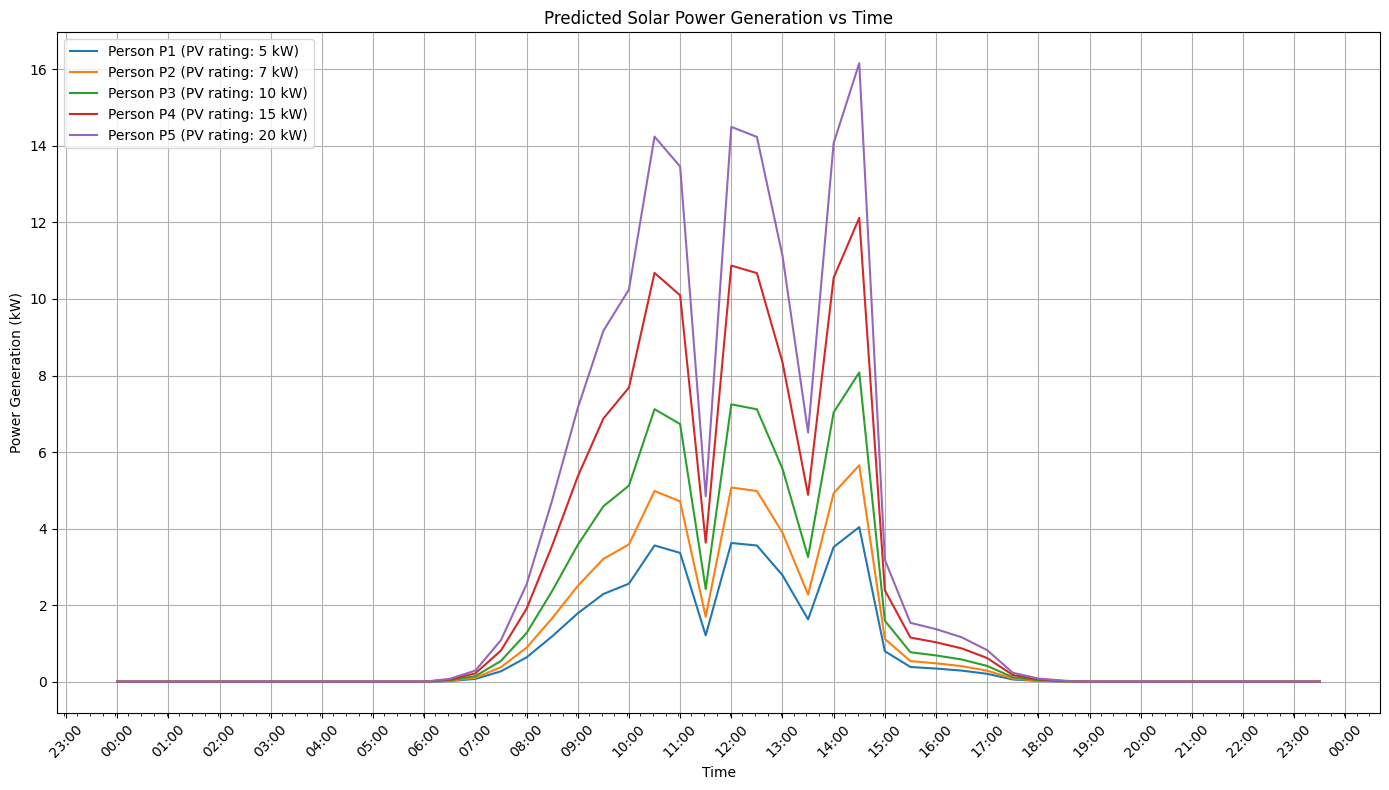

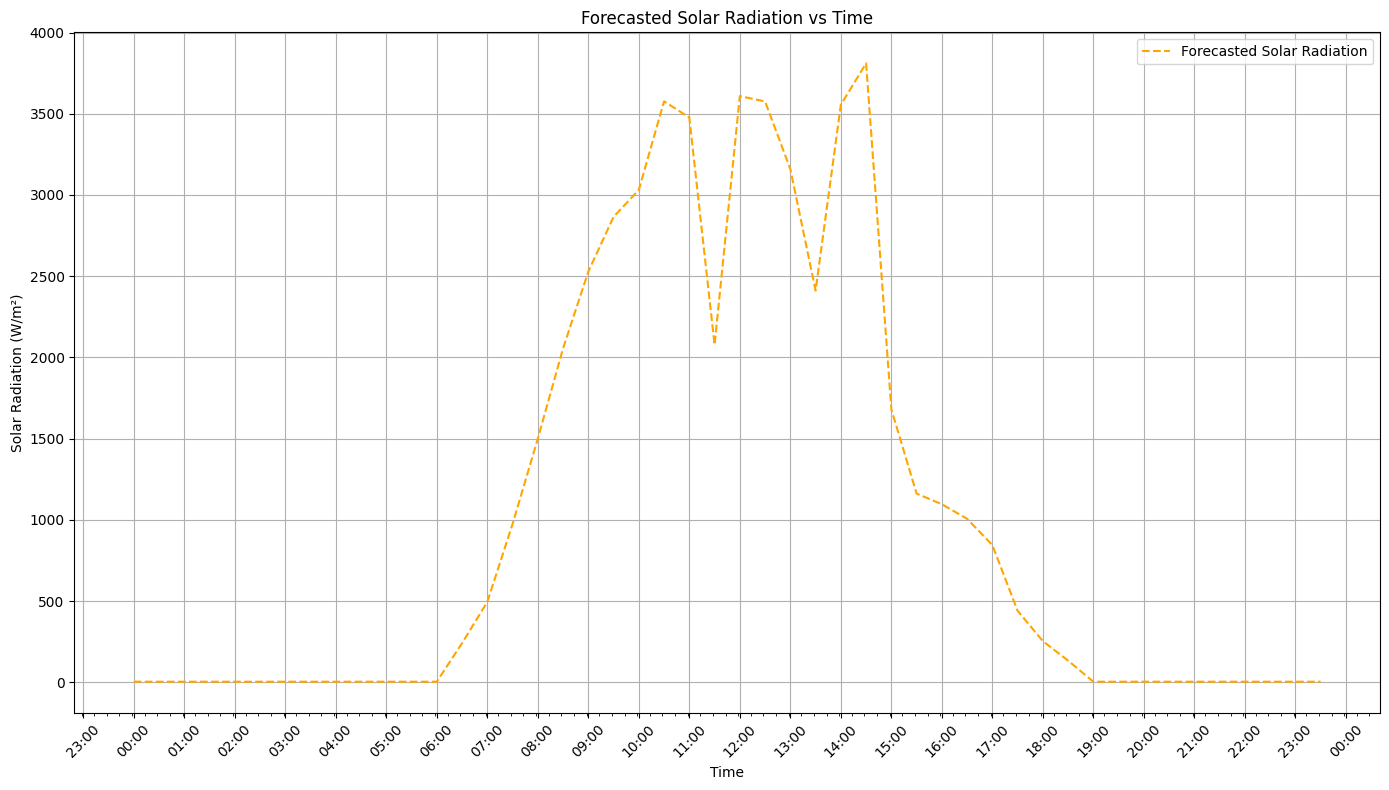

In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# PV ratings for five people
pv_ratings = np.array([5, 7, 10, 15, 20])  # kW ratings for P1, P2, ..., P5
eta = 0.25  # efficiency

# Forecast data preparation
day_temp_pred = day_temp_pred.ravel()
day_rad_pred = day_rad_pred.ravel()
day_PowerConsumption_Zone1_pred = day_PowerConsumption_Zone1_pred.ravel()

# Create a DataFrame with time data
day_data = pd.DataFrame({'DATE_TIME': pd.date_range(start=start_time, periods=len(day_rad_pred), freq='30min')})

# Calculate solar power forecast for each person
for i, rating in enumerate(pv_ratings, start=1):
    T_C_forecasted = day_temp_pred + (NOCT - 20) * (day_rad_pred / G_STC)
    P_PV_forecasted = (rating * eta * P_STC * F_PV * (day_rad_pred / G_STC) *
                       (1 + (T_C_forecasted - T_STC) * C_T)) / 100000
    P_PV_forecasted[P_PV_forecasted < 0] = 0
    day_data[f'P_PV_forecasted_P{i}'] = P_PV_forecasted

# Plotting solar power generation for each person
fig1, ax1 = plt.subplots(figsize=(14, 8))
for i in range(1, 6):
    ax1.plot(day_data['DATE_TIME'], day_data[f'P_PV_forecasted_P{i}'], label=f'Person P{i} (PV rating: {pv_ratings[i-1]} kW)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Power Generation (kW)')
ax1.set_title('Predicted Solar Power Generation vs Time')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_locator(mdates.HourLocator())
ax1.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis='x', rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# Plotting solar radiation
fig2, ax2 = plt.subplots(figsize=(14, 8))
ax2.plot(day_data['DATE_TIME'], day_rad_pred, color='orange', label='Forecasted Solar Radiation', linestyle='--')
ax2.set_xlabel('Time')
ax2.set_ylabel('Solar Radiation (W/m²)')
ax2.set_title('Forecasted Solar Radiation vs Time')
ax2.xaxis.set_major_locator(mdates.HourLocator())
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper right')
plt.grid()
plt.tight_layout()
plt.show()


In [30]:
data.head()

,Date_time,Date,Time,Temperature,Hi Temp,Low Temp,Out Hum,Dew Pt.,WindSpeed,Wind Dir,...,Wind Samp,Wind Tx,ISS Recept,Arc. Int.,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,DATE_TIME,T_C,P_PV
0,01-04-2023 00:30,01-04-2023,00:30,28.0,28.0,27.9,83.0,24.8,1.6,SSE,...,700,1,100.0,30,34.055696,16.128875,20.240964,2023-04-01 00:30:00,28.0,0.0
1,01-04-2023 01:00,01-04-2023,01:00,28.1,28.1,27.9,83.0,24.9,0.0,ESE,...,702,1,100.0,30,29.814684,19.375076,20.131084,2023-04-01 01:00:00,28.1,0.0
2,01-04-2023 01:30,01-04-2023,01:30,27.7,28.1,27.7,84.0,24.8,1.6,S,...,703,1,100.0,30,29.128101,19.006687,19.668434,2023-04-01 01:30:00,27.7,0.0
3,01-04-2023 02:00,01-04-2023,02:00,27.6,27.7,27.6,84.0,24.6,1.6,SSW,...,702,1,100.0,30,28.228861,18.361094,18.899277,2023-04-01 02:00:00,27.6,0.0
4,01-04-2023 02:30,01-04-2023,02:30,27.6,27.6,27.5,85.0,24.8,0.0,SSW,...,703,1,100.0,30,27.335696,17.872340,18.442410,2023-04-01 02:30:00,27.6,0.0


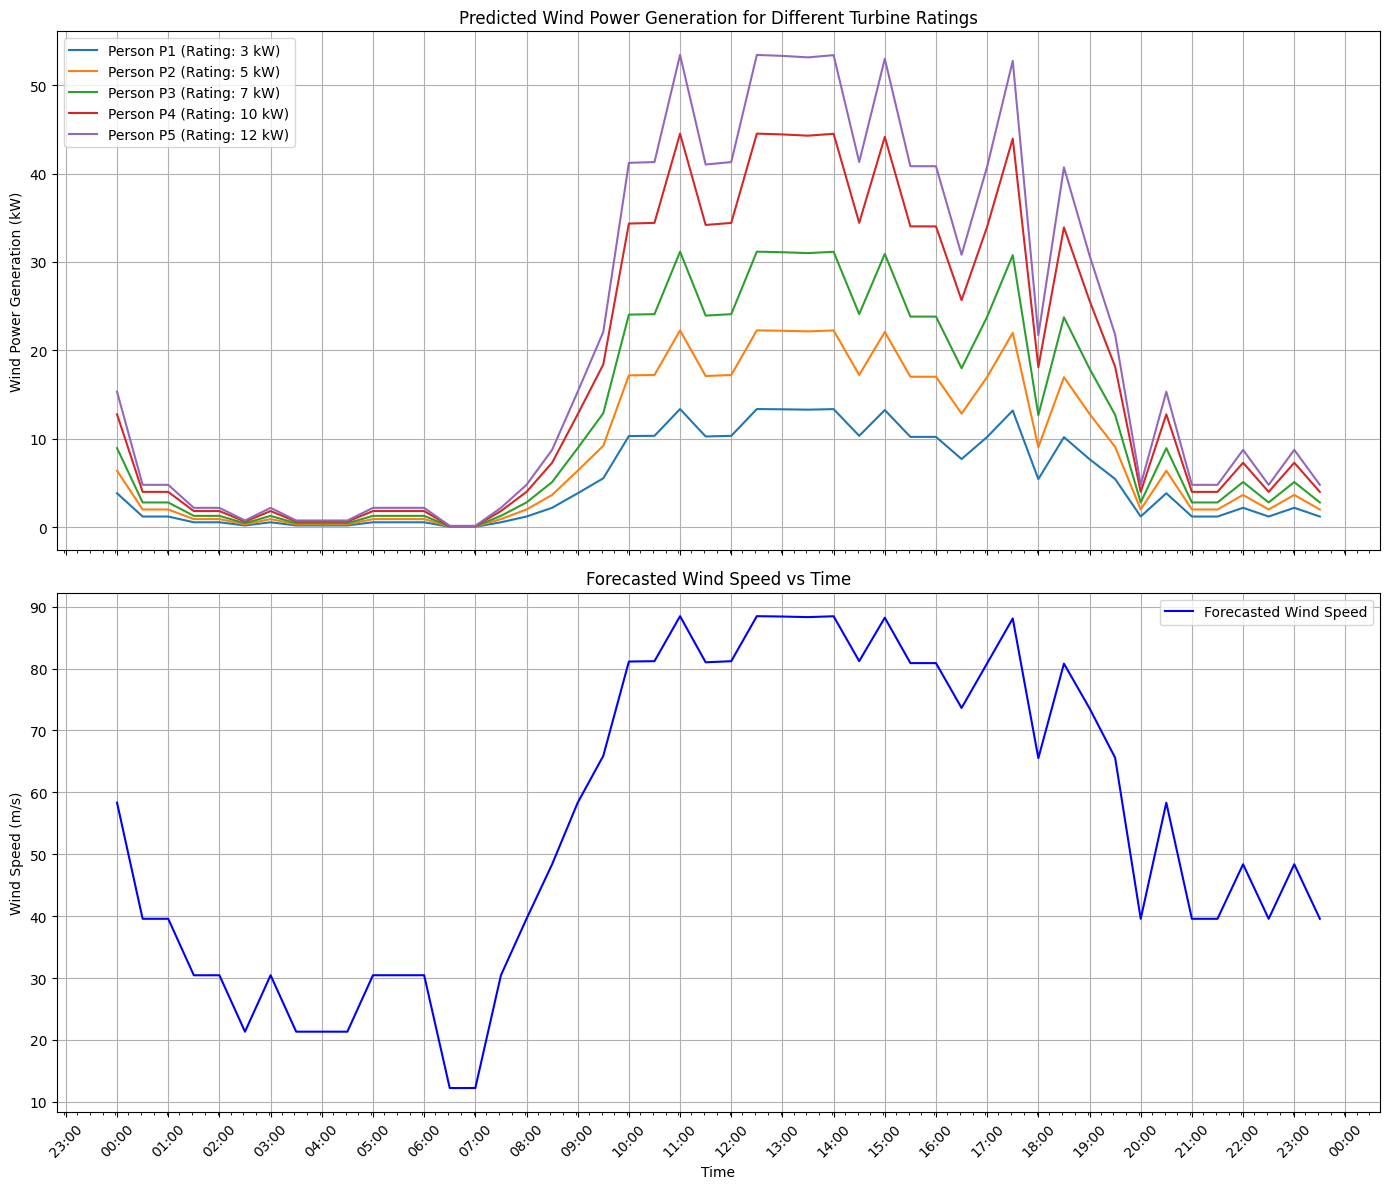

In [39]:
# Define wind turbine ratings for each person in kW
wind_ratings = np.array([3, 5, 7, 10, 12])  # Example ratings in kW for P1, P2, ..., P5
rho = 1.225  # Air density in kg/m³
A = 3        # Swept area in m² (example value)
eta = 0.35   # Efficiency of the turbine

# Ensure wind predictions are in 1D
day_wind_pred = day_wind_pred.ravel()

# Calculate wind power for each person
# day_data = pd.DataFrame({'DATE_TIME': pd.date_range(start=start_time, periods=len(day_wind_pred), freq='30min')})
for i, rating in enumerate(wind_ratings, start=1):
    wind_power_forecasted = (0.5 * rho * A * eta * rating * (day_wind_pred ** 3)) / 100000  # Convert to kW
    wind_power_forecasted[wind_power_forecasted < 0] = 0

    day_data[f'Wind_forecasted_P{i}'] = wind_power_forecasted

# Plotting wind power generation and wind speed
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plotting wind power generation for each person
for i in range(1, 6):
    ax1.plot(day_data['DATE_TIME'], day_data[f'Wind_forecasted_P{i}'], label=f'Person P{i} (Rating: {wind_ratings[i-1]} kW)')

# Customize wind power generation plot
ax1.set_ylabel('Wind Power Generation (kW)')
ax1.set_title('Predicted Wind Power Generation for Different Turbine Ratings')
ax1.legend(loc='upper left')
ax1.grid()

# Plotting forecasted wind speed
ax2.plot(day_data['DATE_TIME'], day_wind_pred, color='blue', label='Forecasted Wind Speed')
ax2.set_xlabel('Time')
ax2.set_ylabel('Wind Speed (m/s)')
ax2.set_title('Forecasted Wind Speed vs Time')
ax2.legend()
ax2.grid()

# Formatting the x-axis to show time every hour with 15-minute minor ticks
ax2.xaxis.set_major_locator(mdates.HourLocator())
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


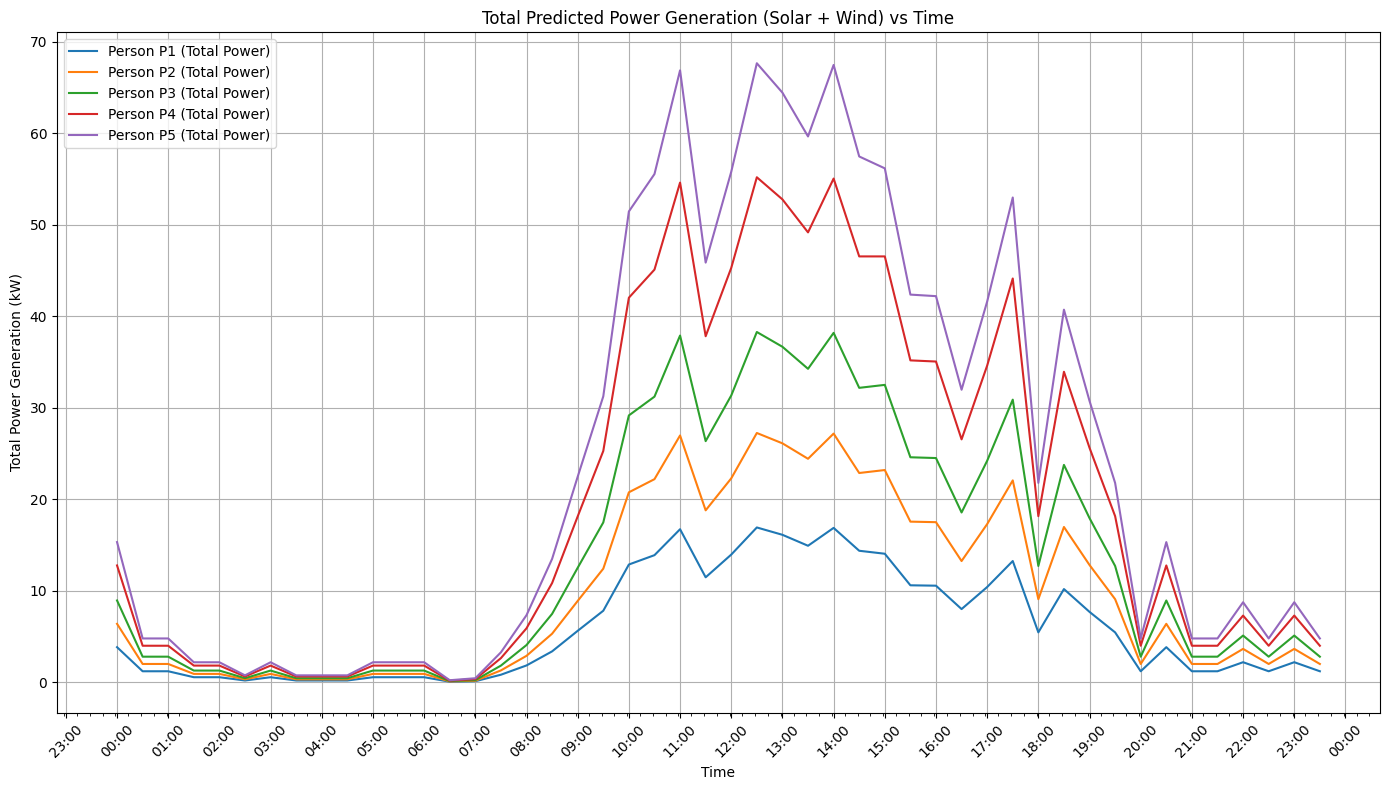

In [40]:
# Adding total power calculation by combining solar and wind power for each person
for i in range(1, 6):
    day_data[f'Total_Power_P{i}'] = day_data[f'P_PV_forecasted_P{i}'] + day_data[f'Wind_forecasted_P{i}']

# Plotting total power generation for each person
fig, ax = plt.subplots(figsize=(14, 8))

for i in range(1, 6):
    ax.plot(day_data['DATE_TIME'], day_data[f'Total_Power_P{i}'], label=f'Person P{i} (Total Power)')

# Customize the plot
ax.set_xlabel('Time')
ax.set_ylabel('Total Power Generation (kW)')
ax.set_title('Total Predicted Power Generation (Solar + Wind) vs Time')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.grid()
plt.show()


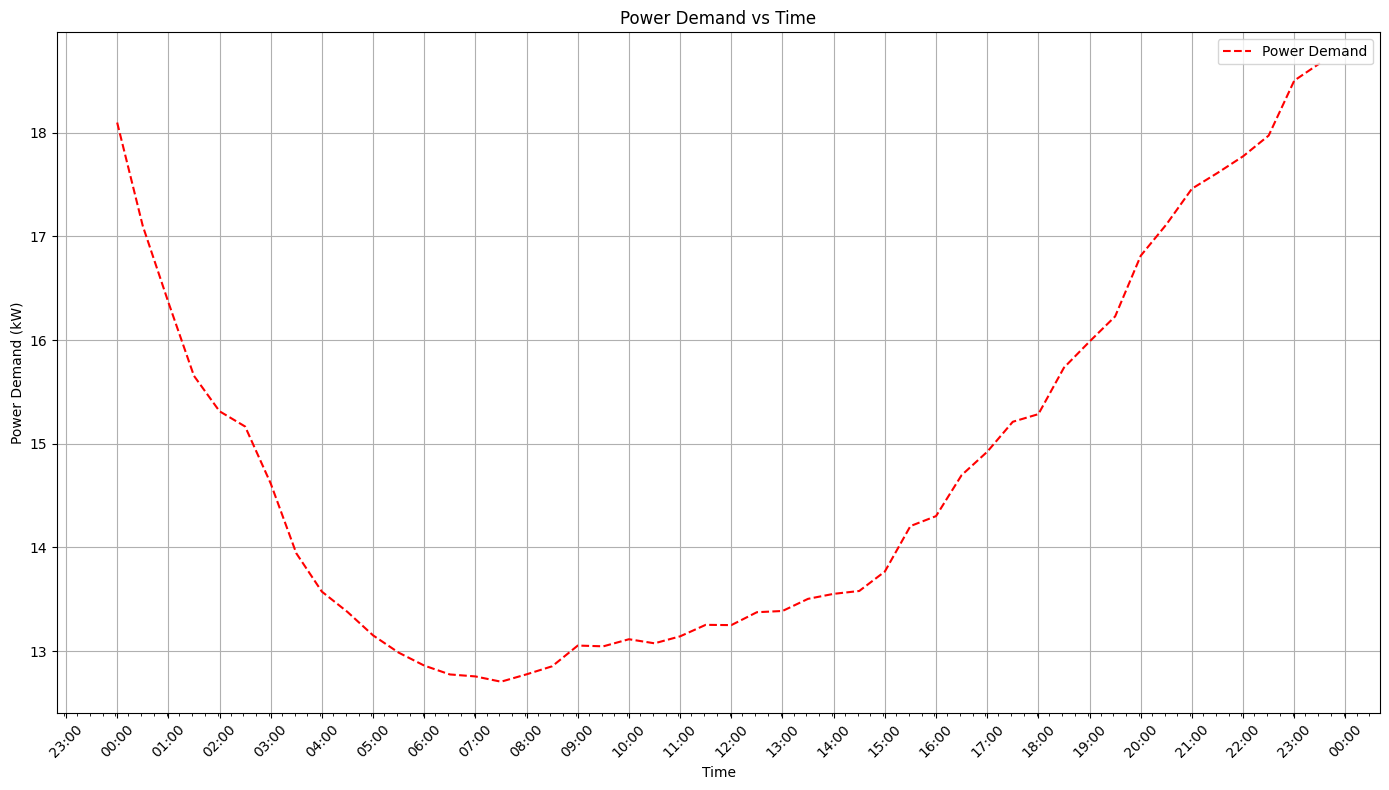

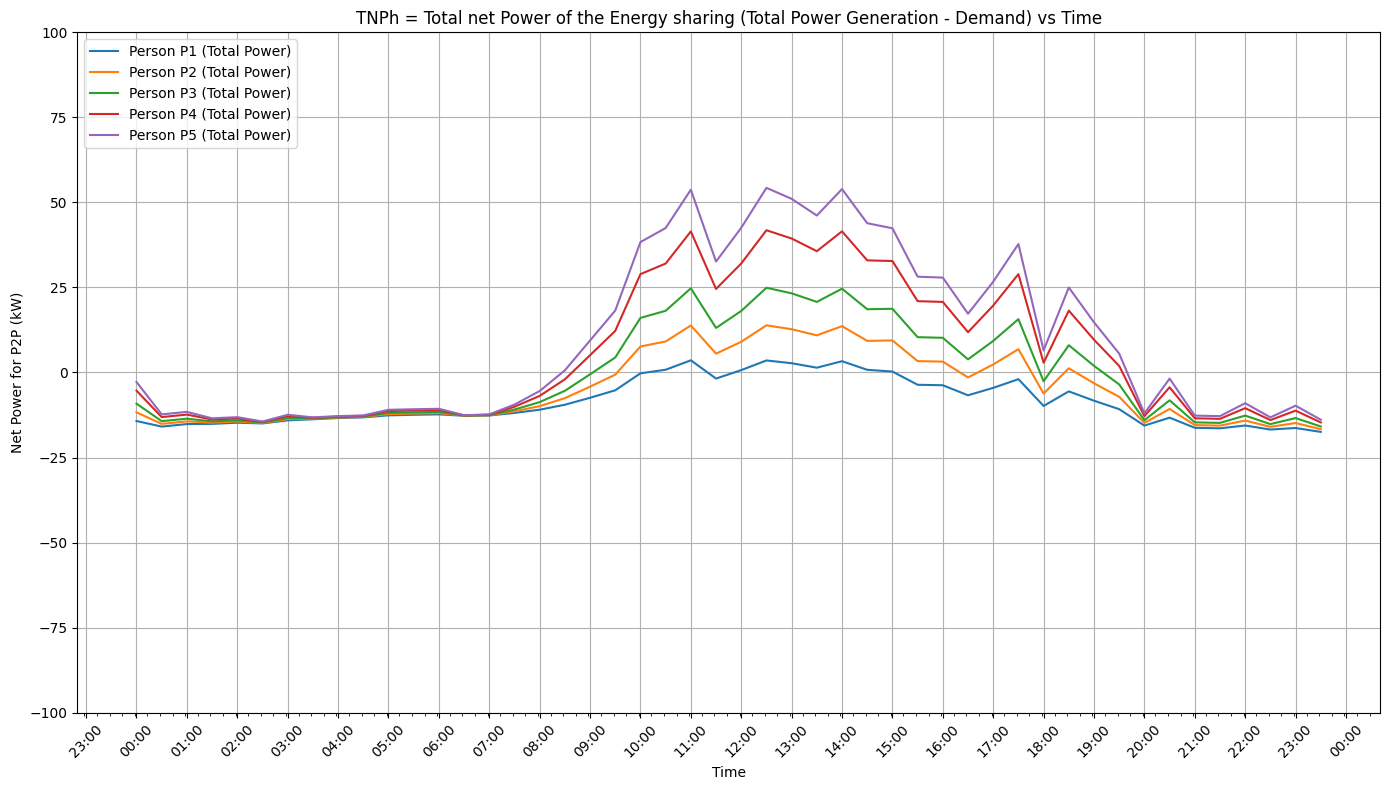

In [47]:

# Plotting power demand
fig2, ax2 = plt.subplots(figsize=(14, 8))
ax2.plot(day_data['DATE_TIME'], day_PowerConsumption_Zone1_pred / 10, color='red', label='Power Demand', linestyle='--')
ax2.set_xlabel('Time')
ax2.set_ylabel('Power Demand (kW)')
ax2.set_title('Power Demand vs Time')
ax2.xaxis.set_major_locator(mdates.HourLocator())
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper right')
plt.grid()
plt.tight_layout()
plt.show()

# Plotting net power demand (Demand - Total Power Generation) for each person
fig3, ax3 = plt.subplots(figsize=(14, 8))
for i in range(1, 6):
    # Net power is demand minus the combined solar and wind power generation
    net_power =  day_data[f'Total_Power_P{i}']-(day_PowerConsumption_Zone1_pred / 10)
    ax3.plot(day_data['DATE_TIME'], net_power, label=f'Person P{i} (Total Power)')
ax3.set_xlabel('Time')
ax3.set_ylabel('Net Power for P2P (kW)')
ax3.set_title('TNPh = Total net Power of the Energy sharing (Total Power Generation - Demand) vs Time')
ax3.set_ylim(-100, 100)  # Adjust y-axis limit for net power generation as needed
ax3.legend(loc='upper left')
ax3.xaxis.set_major_locator(mdates.HourLocator())
ax3.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax3.tick_params(axis='x', rotation=45)
plt.grid()
plt.tight_layout()
plt.show()